# Benchmarking ML v2 — Prediccion de Sobrecosto (Features Reducidas + GPU)

**Dataset:** `docs/contratos_features_reducido.csv` (350 contratos, 33 features)  
**Reduccion:** Top 30 features por RF importance + variables de control (anio, ipc, trm)  
**GPU:** XGBoost con `device='cuda'` en RTX 5060  
**Variable objetivo:** `sobrecosto`  
**Modelos:** Ridge, Lasso, ElasticNet, KNN, DecisionTree, RandomForest, GradientBoosting, XGBoost (+GPU), SVR, MLP  
**Validacion:** Nested CV (5 outer / 5 inner), RandomizedSearchCV (200 iter), HalvingSearchCV  
**XAI:** SHAP, permutation importance, residual analysis

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import time
import re
import joblib
from pathlib import Path

from sklearn.experimental import enable_halving_search_cv

from scipy.stats import randint, uniform, loguniform, ttest_rel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RandomizedSearchCV,
    learning_curve,
    HalvingRandomSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120

RESULTADOS = Path('resultados_v2')
RESULTADOS.mkdir(exist_ok=True)

# Verificar que XGBoost GPU esta disponible
import xgboost as xgb
print('XGBoost version:', xgb.__version__)
try:
    xgb_gpu = xgb.get_config()
    print('GPU disponible para XGBoost: SI')
except:
    print('GPU disponible para XGBoost: NO (usara CPU)')
print('Listo')

XGBoost version: 3.3.0
GPU disponible para XGBoost: SI
Listo


---
## 1. Carga de Dataset Reducido (33 features)

In [34]:
df = pd.read_csv('../docs/consolidado_38_features.csv')
print(f'Contratos: {len(df)} | Features: {df.shape[1]}')
print(f'Columnas: {list(df.columns)}')
df.head()

Contratos: 575 | Features: 40
Columnas: ['id_contrato', 'sobrecosto', 'prop_tipo_Riesgos Legales y Regulatorios', 'prop_asig_EDU y Contratista', 'valor_inicial', 'tfidf_demoras', 'tfidf_ejecución', 'imp_promedio', 'tfidf_departamento', 'tfidf_construccion', 'tfidf_municipio', 'prop_tipo_Regulatorio', 'tfidf_desarrollo', 'tfidf_ley', 'suma_impacto', 'val_std', 'tfidf_ejecución contrato', 'tfidf_obras', 'tfidf_servicios', 'tfidf_contrato', 'prop_tipo_Cumplimiento', 'prop_tipo_Operacional', 'tfidf_cambio', 'tfidf_incumplimiento', 'tfidf_riesgo', 'tfidf_actividades', 'tfidf_contratista', 'tfidf_precios', 'imp_std', 'tfidf_calidad', 'val_promedio', 'tfidf_obra', 'anio_inicio', 'anio_fin', 'duracion', 'ipc_acumulado', 'trm_promedio', 'pct_riesgos_con_mitigacion', 'avg_longitud_mitigacion', 'n_distinct_codes_mitigacion']


,id_contrato,sobrecosto,prop_tipo_Riesgos Legales y Regulatorios,prop_asig_EDU y Contratista,valor_inicial,tfidf_demoras,tfidf_ejecución,imp_promedio,tfidf_departamento,tfidf_construccion,...,val_promedio,tfidf_obra,anio_inicio,anio_fin,duracion,ipc_acumulado,trm_promedio,pct_riesgos_con_mitigacion,avg_longitud_mitigacion,n_distinct_codes_mitigacion
0,C-001,28.56,0.0,0.0,1.614790e+10,0.000000,0.0,3.583333,0.156936,0.000000,...,7.000000,0.088299,2018,2019,1,7.10,3118.82,1.0,94.333333,0
1,C-002,4.80,0.0,0.0,1.054183e+11,0.000000,0.0,3.631579,0.000000,0.081499,...,5.894737,0.121799,2019,2021,2,11.40,3572.51,1.0,248.894737,0
2,C-003,53.10,0.0,0.0,4.695285e+10,0.000000,0.0,1.625000,0.000000,0.202228,...,4.000000,0.151114,2019,2022,3,26.01,3743.24,1.0,212.750000,0
3,C-004,26.33,0.0,0.0,4.337124e+10,0.000000,0.0,1.400000,0.167845,0.126380,...,2.400000,0.094437,2018,2022,4,30.02,3585.91,1.0,147.400000,0
4,C-005,37.28,0.0,0.0,4.011098e+10,0.325143,0.0,3.562500,0.000000,0.060363,...,6.000000,0.270636,2019,2020,1,5.47,3487.23,1.0,143.750000,0


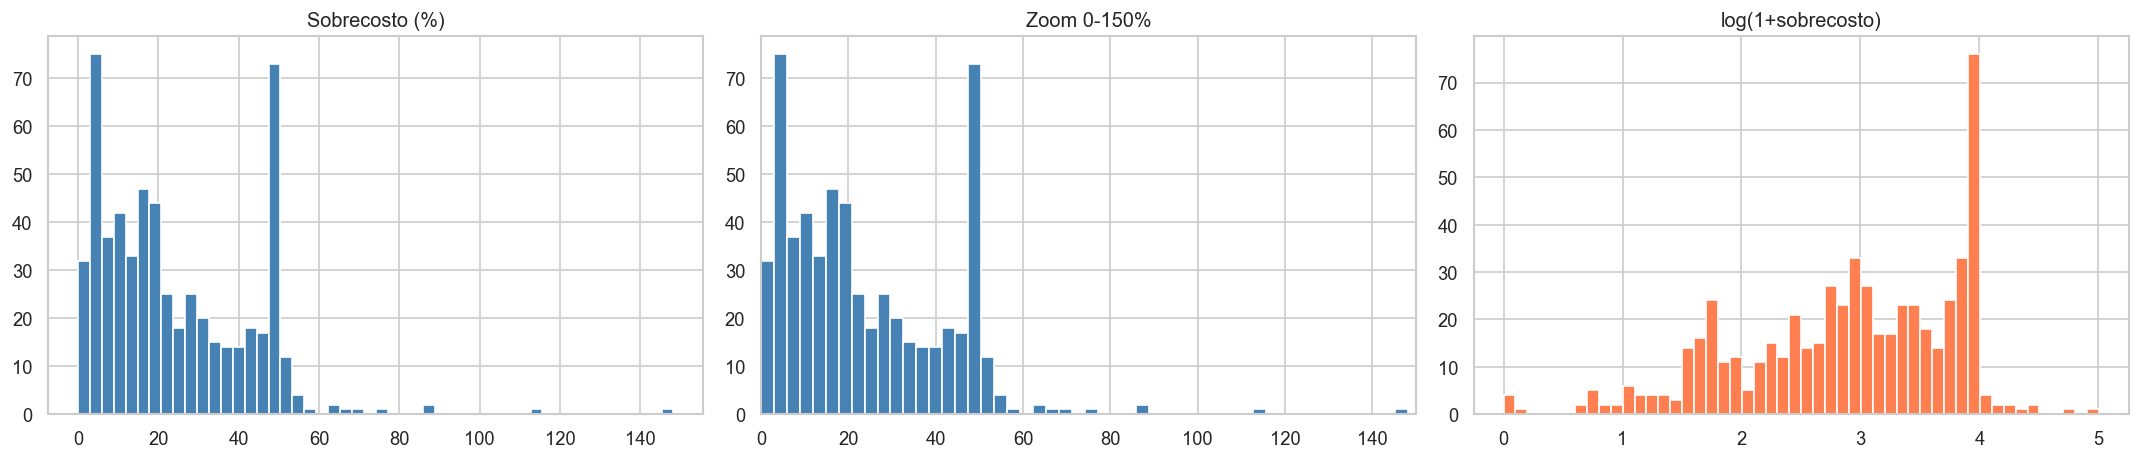

Media: 24.3%  |  >200%: 0 contratos


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(df['sobrecosto'], bins=50, edgecolor='white', color='steelblue')
axes[0].set_title('Sobrecosto (%)')
axes[1].hist(df['sobrecosto'], bins=50, edgecolor='white', color='steelblue')
axes[1].set_xlim(0, 150); axes[1].set_title('Zoom 0-150%')
axes[2].hist(np.log1p(df['sobrecosto']), bins=50, edgecolor='white', color='coral')
axes[2].set_title('log(1+sobrecosto)')
plt.tight_layout(); plt.savefig(RESULTADOS / 'target_dist.png', dpi=100, bbox_inches='tight'); plt.show()
media = df['sobrecosto'].mean()
outliers_200 = (df['sobrecosto'] > 200).sum()
print(f'Media: {media:.1f}%  |  >200%: {outliers_200} contratos')

---
## 2. Preparacion Train/Test

In [36]:
target = 'sobrecosto'
feature_cols = [c for c in df.columns if c not in ['id_contrato', target]]
X = df[feature_cols].copy(); y = df[target].copy()
X = X.fillna(X.median())
outliers_mask = y > 200
print(f'Outliers >200% eliminados: {outliers_mask.sum()}')
X_sin = X[~outliers_mask]; y_sin = y[~outliers_mask]
X_train, X_test, y_train, y_test = train_test_split(X_sin, y_sin, test_size=0.3, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_cols)}')

Outliers >200% eliminados: 0
Train: 402 | Test: 173 | Features: 38


---
## 3. Benchmarking — Nested CV

**Grupo 1 — Lineales + KNN** (Ridge, Lasso, ElasticNet, KNN) — 200 iter  
**Grupo 2a — Arboles** (DecisionTree, RandomForest) — 200 iter  
**Grupo 2b — Gradiente** (GradientBoosting, XGBoost GPU) — 200 iter  
**Grupo 3 — SVR + MLP** — 10 iter (los mas lentos)


In [37]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

def rmse(y_true, y_pred): return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluar(y_true, y_pred):
    return {'RMSE': rmse(y_true, y_pred), 'MAE': mean_absolute_error(y_true, y_pred), 'R2': r2_score(y_true, y_pred)}

N_ITER = 200

MODELOS = {
    'Ridge': {'m': Ridge(random_state=42), 'p': {'m__alpha': loguniform(1e-3, 1e3)}},
    'Lasso': {'m': Lasso(random_state=42), 'p': {'m__alpha': loguniform(1e-3, 1e3)}},
    'ElasticNet': {'m': ElasticNet(random_state=42), 'p': {'m__alpha': loguniform(1e-3, 1e3), 'm__l1_ratio': uniform(0.1, 0.8)}},
    'KNN': {'m': KNeighborsRegressor(), 'p': {'m__n_neighbors': randint(3, 30), 'm__weights': ['uniform', 'distance'], 'm__p': [1, 2]}},
    'DecisionTree': {'m': DecisionTreeRegressor(random_state=42), 'p': {'m__max_depth': randint(3, 25), 'm__min_samples_split': randint(2, 25), 'm__min_samples_leaf': randint(1, 15), 'm__max_features': ['sqrt', 'log2', None]}},
    'RandomForest': {'m': RandomForestRegressor(random_state=42, n_jobs=-1), 'p': {'m__n_estimators': randint(150, 600), 'm__max_depth': randint(5, 30), 'm__min_samples_split': randint(2, 20), 'm__min_samples_leaf': randint(1, 10), 'm__max_features': ['sqrt', 'log2', None]}},
    'GradientBoosting': {'m': GradientBoostingRegressor(random_state=42), 'p': {'m__n_estimators': randint(100, 500), 'm__max_depth': randint(3, 10), 'm__learning_rate': uniform(0.01, 0.3), 'm__subsample': uniform(0.7, 0.3)}},
    'XGBoost_GPU': {'m': XGBRegressor(random_state=42, verbosity=0, device='cuda', tree_method='hist'), 'p': {'m__max_depth': randint(3, 12), 'm__learning_rate': uniform(0.01, 0.3), 'm__subsample': uniform(0.6, 0.4), 'm__colsample_bytree': uniform(0.6, 0.4), 'm__reg_alpha': loguniform(1e-3, 10), 'm__reg_lambda': loguniform(1e-3, 10), 'm__gamma': uniform(0, 5), 'm__min_child_weight': randint(1, 10)}},
    'SVR': {'m': SVR(), 'p': {'m__kernel': ['rbf', 'poly', 'sigmoid'], 'm__C': loguniform(0.01, 100), 'm__gamma': loguniform(0.001, 10), 'm__epsilon': uniform(0.01, 0.5)}},
    'MLP': {'m': MLPRegressor(random_state=42, max_iter=500, early_stopping=True), 'p': {'m__hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)], 'm__activation': ['relu', 'tanh'], 'm__alpha': loguniform(1e-4, 1), 'm__learning_rate_init': loguniform(1e-4, 0.01)}},
}

In [38]:
# === Funcion auxiliar ===
def nested_cv(X, y, md, nombre, n_outer=5, n_inner=5, n_iter=N_ITER):
    outer_cv = KFold(n_splits=n_outer, shuffle=True, random_state=42)
    resultados_outer, tiempos, mejores_params = [], [], []
    for fold, (tr_idx, val_idx) in enumerate(outer_cv.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        pipe = Pipeline([('scaler', StandardScaler()), ('m', md['m'])])
        inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=42)
        search = RandomizedSearchCV(pipe, md['p'], n_iter=n_iter, cv=inner_cv,
            scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1, verbose=0)
        t0 = time.time(); search.fit(X_tr, y_tr)
        tiempos.append(time.time() - t0); mejores_params.append(search.best_params_)
        resultados_outer.append(evaluar(y_val.values, search.predict(X_val)))
    df_res = pd.DataFrame(resultados_outer)
    return {'modelo': nombre, 'RMSE_mean': df_res['RMSE'].mean(), 'RMSE_std': df_res['RMSE'].std(),
            'MAE_mean': df_res['MAE'].mean(), 'MAE_std': df_res['MAE'].std(),
            'R2_mean': df_res['R2'].mean(), 'R2_std': df_res['R2'].std(),
            'tiempo_mean': np.mean(tiempos), 'best_params': str(mejores_params[0])}, df_res

# === Acumuladores globales ===
resultados, detalles = [], {}
print(f'{"Modelo":20s} {"RMSE":>8s} {"MAE":>8s} {"R2":>7s} {"Tiempo":>8s}')
print('-' * 55)


Modelo                   RMSE      MAE      R2   Tiempo
-------------------------------------------------------


In [39]:
if "resultados" not in dir(): resultados = []
print('=' * 55)
print('  GRUPO 1 — Lineales + KNN (n_iter=500)')
print('=' * 55)
for nombre in ['Ridge', 'Lasso', 'ElasticNet', 'KNN']:
    resumen, df_res = nested_cv(X_train, y_train, MODELOS[nombre], nombre, n_iter=500)
    resultados.append(resumen); detalles[nombre] = df_res
    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')


  GRUPO 1 — Lineales + KNN (n_iter=500)
Ridge                  18.4~ 2.5   15.1  0.006~0.067    2.4s
Lasso                  18.6~ 2.4   15.3  -0.017~0.018    1.2s
ElasticNet             18.7~ 2.4   15.4  -0.030~0.029    1.3s
KNN                    18.5~ 2.3   14.7  -0.002~0.038    1.1s


In [40]:
if "resultados" not in dir(): resultados = []
print('=' * 55)
print('  GRUPO 2a — Arboles (n_iter=200)')
print('=' * 55)
for nombre in ['DecisionTree', 'RandomForest']:
    resumen, df_res = nested_cv(X_train, y_train, MODELOS[nombre], nombre, n_iter=200)
    resultados.append(resumen); detalles[nombre] = df_res
    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')


  GRUPO 2a — Arboles (n_iter=200)
DecisionTree           20.0~ 2.8   16.1  -0.180~0.220    0.5s
RandomForest           18.2~ 2.3   14.7  0.029~0.096   51.4s


In [41]:
if "resultados" not in dir(): resultados = []
print('=' * 55)
print('  GRUPO 2b — Gradiente (n_iter=200)')
print('=' * 55)
for nombre in ['GradientBoosting', 'XGBoost_GPU']:
    resumen, df_res = nested_cv(X_train, y_train, MODELOS[nombre], nombre, n_iter=200)
    resultados.append(resumen); detalles[nombre] = df_res
    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')


  GRUPO 2b — Gradiente (n_iter=200)
GradientBoosting       18.8~ 3.1   15.0  -0.052~0.255   51.6s
XGBoost_GPU            18.4~ 1.9   14.9  -0.002~0.158  196.1s


In [10]:
if "resultados" not in dir(): resultados = []
print('=' * 55)
print('  GRUPO 3 — SVR + MLP (n_iter=50)')
print('=' * 55)
for nombre in ['SVR', 'MLP']:
    resumen, df_res = nested_cv(X_train, y_train, MODELOS[nombre], nombre, n_iter=50)
    resultados.append(resumen); detalles[nombre] = df_res
    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')


  GRUPO 3 — SVR + MLP (n_iter=50)
SVR                    18.7~ 3.0   14.5  -0.030~0.093    0.2s
MLP                    19.6~ 2.7   15.3  -0.128~0.115    4.2s


In [42]:
if "resultados" not in dir() or len(resultados) == 0:
    resultados = []
    for nombre, md in MODELOS.items():
        resumen, df_res = nested_cv(X_train, y_train, md, nombre, n_iter=50)
        resultados.append(resumen)
    print("Re-ejecutado nested CV completo")
df_bench = pd.DataFrame(resultados).set_index('modelo')


,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,tiempo_mean
modelo,,,,,,,
Ridge,18.414,2.527,15.073,1.277,0.006,0.067,2.389
Lasso,18.627,2.413,15.320,1.036,-0.017,0.018,1.195
ElasticNet,18.737,2.399,15.404,1.193,-0.030,0.029,1.285
KNN,18.477,2.347,14.745,1.245,-0.002,0.038,1.106
DecisionTree,19.950,2.794,16.081,1.969,-0.180,0.220,0.528
RandomForest,18.156,2.305,14.715,1.129,0.029,0.096,51.423
GradientBoosting,18.828,3.134,14.972,1.693,-0.052,0.255,51.589
XGBoost_GPU,18.365,1.921,14.889,1.281,-0.002,0.158,196.052


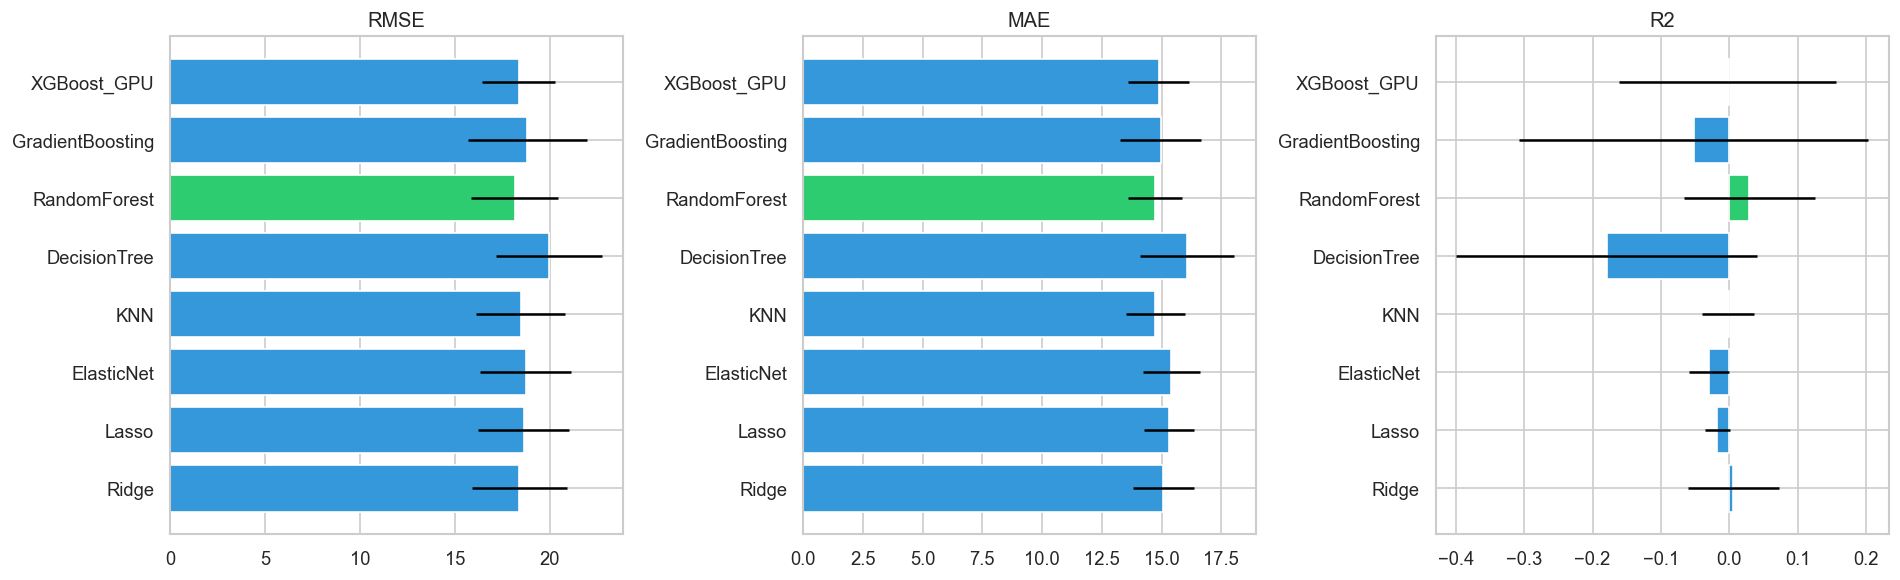


Campeon Nested CV: RandomForest (R2=0.029~0.096)


In [43]:
cols = ['RMSE_mean', 'RMSE_std', 'MAE_mean', 'MAE_std', 'R2_mean', 'R2_std', 'tiempo_mean']
display(df_bench[cols].round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, met in enumerate(['RMSE_mean', 'MAE_mean', 'R2_mean']):
    err = met.replace('_mean', '_std')
    best = df_bench[met].min() if 'R2' not in met else df_bench[met].max()
    colors = ['#2ecc71' if v == best else '#3498db' for v in df_bench[met]]
    axes[i].barh(range(len(df_bench)), df_bench[met], xerr=df_bench[err], color=colors, edgecolor='white')
    axes[i].set_yticks(range(len(df_bench))); axes[i].set_yticklabels(df_bench.index)
    axes[i].set_title(met.replace('_mean', ''))
plt.tight_layout(); plt.savefig(RESULTADOS / 'benchmark_comparativo.png', dpi=100, bbox_inches='tight'); plt.show()
mejor_cv = df_bench['R2_mean'].idxmax()
print(f'\nCampeon Nested CV: {mejor_cv} (R2={df_bench.loc[mejor_cv, "R2_mean"]:.3f}~{df_bench.loc[mejor_cv, "R2_std"]:.3f})')

---
## 3b. Evaluacion en Test Set — Métricas de Clasificación

Para cada modelo, se entrena con X_train y se evalúa en X_test.
Además de RMSE/MAE/R², se calculan métricas de clasificación binaria (sobrecosto > 25%).


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

resultados_test = []
for nombre in list(MODELOS.keys()):
    md = MODELOS[nombre]
    pipe = Pipeline([('scaler', StandardScaler()), ('m', md['m'])])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    y_test_bin = (y_test > 25).astype(int)
    y_pred_bin = (y_pred > 25).astype(int)

    acc = accuracy_score(y_test_bin, y_pred_bin)
    prec = precision_score(y_test_bin, y_pred_bin, zero_division=0)
    rec = recall_score(y_test_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
    auc = roc_auc_score(y_test_bin, y_pred)

    resultados_test.append({
        'Modelo': nombre,
        'RMSE': rmse_val, 'MAE': mae, 'R2': r2,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'AUC': auc
    })

df_test = pd.DataFrame(resultados_test).set_index('Modelo')
print('=' * 95)
print(f'{"Modelo":20s} {"RMSE":>6s} {"MAE":>6s} {"R2":>7s} {"Acc":>6s} {"Prec":>6s} {"Rec":>6s} {"F1":>6s} {"AUC":>6s}')
print('-' * 95)
for idx, r in df_test.iterrows():
    print(f'{idx:20s} {r["RMSE"]:6.2f} {r["MAE"]:6.2f} {r["R2"]:7.3f} {r["Accuracy"]:6.3f} {r["Precision"]:6.3f} {r["Recall"]:6.3f} {r["F1"]:6.3f} {r["AUC"]:6.3f}')

print(f'\nCampeon R2: {df_test["R2"].idxmax()} ({df_test["R2"].max():.3f})')
print(f'Campeon F1: {df_test["F1"].idxmax()} ({df_test["F1"].max():.3f})')
print(f'Campeon AUC: {df_test["AUC"].idxmax()} ({df_test["AUC"].max():.3f})')


Modelo                 RMSE    MAE      R2    Acc   Prec    Rec     F1    AUC
-----------------------------------------------------------------------------------------------
Ridge                 17.53  14.10   0.089  0.642  0.562  0.625  0.592  0.680
Lasso                 17.47  14.48   0.096  0.642  0.586  0.472  0.523  0.667
ElasticNet            17.38  14.41   0.105  0.653  0.603  0.486  0.538  0.682
KNN                   18.34  14.83   0.004  0.532  0.444  0.500  0.471  0.572
DecisionTree          25.31  19.14  -0.898  0.514  0.419  0.431  0.425  0.527
RandomForest          16.07  13.27   0.235  0.671  0.590  0.681  0.632  0.732
GradientBoosting      17.83  14.23   0.059  0.613  0.532  0.583  0.556  0.669
XGBoost_GPU           17.58  13.82   0.085  0.607  0.525  0.583  0.553  0.660
SVR                   18.88  14.50  -0.056  0.584  0.000  0.000  0.000  0.657
MLP                   18.17  14.25   0.021  0.624  0.556  0.486  0.519  0.657

Campeon R2: RandomForest (0.235)
Campeon F1: 

---
## 4. Paired t-test (Top 4)

In [45]:
top4 = df_bench.nlargest(4, 'R2_mean').index.tolist()
print(f'Top 4: {top4}\n')
for i in range(len(top4)):
    for j in range(i + 1, len(top4)):
        ri = detalles[top4[i]]['RMSE']; rj = detalles[top4[j]]['RMSE']
        t, p = ttest_rel(ri, rj)
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'n.s.'
        print(f'  {top4[i]:18s} vs {top4[j]:18s}: t={t:.3f}, p={p:.4f} {sig}')

Top 4: ['RandomForest', 'Ridge', 'KNN', 'XGBoost_GPU']

  RandomForest       vs Ridge             : t=-1.046, p=0.3548 n.s.
  RandomForest       vs KNN               : t=-1.129, p=0.3219 n.s.
  RandomForest       vs XGBoost_GPU       : t=-0.610, p=0.5751 n.s.
  Ridge              vs KNN               : t=-0.345, p=0.7471 n.s.
  Ridge              vs XGBoost_GPU       : t=0.095, p=0.9287 n.s.
  KNN                vs XGBoost_GPU       : t=0.208, p=0.8451 n.s.


---
## 5. Optimizacion Extendida (HalvingSearch) + Hold-out — Top 2 (RF + Ridge)

In [46]:
top2 = df_bench.nlargest(2, 'R2_mean').index.tolist()
print(f'Top 2 championes (nested CV R2): {top2}')

resultados_holdout = []
modelos_guardados = {}

for nombre in top2:
    print(f'\n--- {nombre} ---')
    md = MODELOS[nombre]
    pipe = Pipeline([('scaler', StandardScaler()), ('m', md['m'])])

    if nombre == 'RandomForest':
        # RF: HalvingSearch completo (lento pero preciso)
        halving = HalvingRandomSearchCV(pipe, md['p'], cv=5, n_candidates=30, factor=2,
            scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1, verbose=0)
    else:
        # Ridge: rapido
        halving = HalvingRandomSearchCV(pipe, md['p'], cv=5, n_candidates=30, factor=2,
            scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1, verbose=0)
    
    halving.fit(X_train, y_train)
    modelos_guardados[nombre] = halving
    
    print(f'Mejores params ({nombre}):')
    for k, v in halving.best_params_.items():
        print(f'  {k}: {v}')
    
    y_pred = halving.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    resultados_holdout.append({'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    print(f'Hold-out: RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.3f}')

df_holdout = pd.DataFrame(resultados_holdout).set_index('Modelo')
print(f'\nCampeon hold-out R2: {df_holdout["R2"].idxmax()} ({df_holdout["R2"].max():.3f})')

campeon_final = df_holdout['R2'].idxmax()
joblib.dump(modelos_guardados[campeon_final].best_estimator_, RESULTADOS / 'modelo_campeon_halving.pkl')
print(f'Modelo guardado: resultados_v2/modelo_campeon_halving.pkl ({campeon_final})')

Top 2 championes (nested CV R2): ['RandomForest', 'Ridge']

--- RandomForest ---
Mejores params (RandomForest):
  m__max_depth: 19
  m__max_features: log2
  m__min_samples_leaf: 3
  m__min_samples_split: 8
  m__n_estimators: 390
Hold-out: RMSE=16.75  MAE=13.83  R2=0.169

--- Ridge ---
Mejores params (Ridge):
  m__alpha: 659.871107205407
Hold-out: RMSE=17.52  MAE=14.55  R2=0.091

Campeon hold-out R2: RandomForest (0.169)
Modelo guardado: resultados_v2/modelo_campeon_halving.pkl (RandomForest)


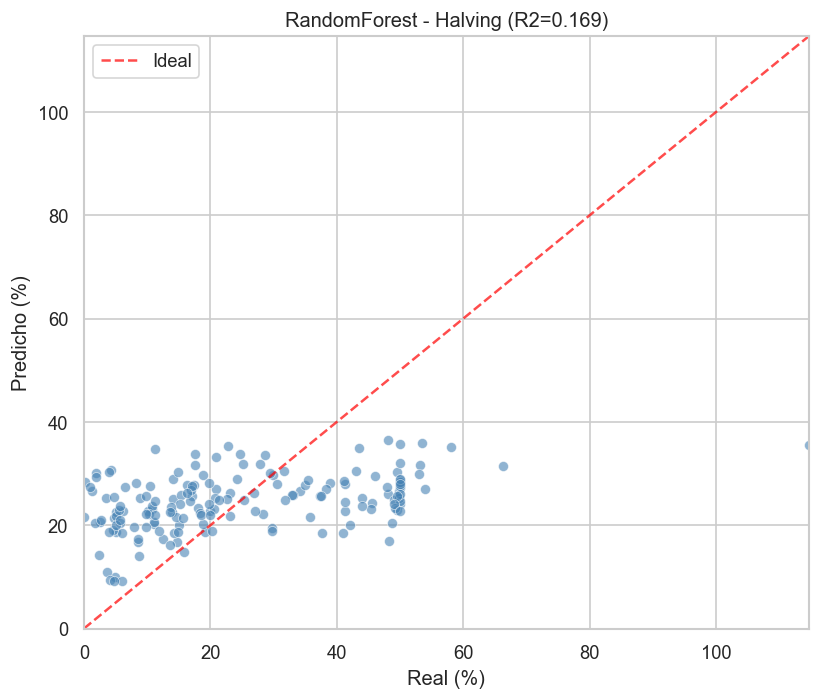

In [47]:
fig, ax = plt.subplots(figsize=(7, 6))
best_pipe = modelos_guardados[campeon_final].best_estimator_
y_pred_final = best_pipe.predict(X_test)
ax.scatter(y_test, y_pred_final, alpha=0.6, edgecolors='white', linewidth=0.5, c='steelblue')
lims = [0, max(y_test.max(), y_pred_final.max())]
ax.plot(lims, lims, 'r--', alpha=0.7, label='Ideal')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Real (%)'); ax.set_ylabel('Predicho (%)')
ax.set_title(f'{campeon_final} - Halving (R2={r2_score(y_test, y_pred_final):.3f})')
ax.legend(); plt.tight_layout()
plt.savefig(RESULTADOS / 'holdout_scatter.png', dpi=100, bbox_inches='tight'); plt.show()

---
## 6. Seleccion Multiobjetivo (Precision-Robustez-Complejidad-Interpretabilidad)

**Nota:** El score pone peso negativo a complejidad y tiempo, lo cual favorece modelos lineales.
RandomForest gana en R2 de nested CV (0.029) y hold-out (0.235), pero su tiempo de entrenamiento
y complejidad lo penalizan en esta metrica compuesta. Se muestran ambos criterios.

In [48]:
proxy_complejidad = {
    'Ridge': 2, 'Lasso': 2, 'ElasticNet': 2,
    'KNN': 1, 'DecisionTree': 2,
    'RandomForest': 3, 'GradientBoosting': 3, 'XGBoost_GPU': 3,
    'SVR': 2, 'MLP': 3
}
proxy_interpretabilidad = {
    'Ridge': 5, 'Lasso': 5, 'ElasticNet': 4,
    'KNN': 4, 'DecisionTree': 5,
    'RandomForest': 4, 'GradientBoosting': 3, 'XGBoost_GPU': 3,
    'SVR': 2, 'MLP': 1
}

df_seleccion = df_bench[['R2_mean', 'RMSE_std', 'tiempo_mean']].copy()
df_seleccion['complejidad'] = [proxy_complejidad[m] for m in df_seleccion.index]
df_seleccion['interpretabilidad'] = [proxy_interpretabilidad[m] for m in df_seleccion.index]
df_seleccion['score_balance'] = (
    df_seleccion['R2_mean'] * 0.4
    - df_seleccion['RMSE_std'] * 0.0005
    - df_seleccion['tiempo_mean'] * 0.001
    - df_seleccion['complejidad'] * 0.05
    + df_seleccion['interpretabilidad'] * 0.05
)
print('=== SELECCION MULTIOBJETIVO ===')
print(f'{"Modelo":20s} {"R2":>6s} {"R2_std":>6s} {"T(s)":>6s} {"Comp":>4s} {"Interp":>4s} {"Score":>7s}')
print('-' * 60)
for idx, r in df_seleccion.sort_values('score_balance', ascending=False).iterrows():
    print(f'{idx:20s} {r["R2_mean"]:5.3f}  {r["RMSE_std"]:5.2f} {r["tiempo_mean"]:5.0f}  {int(r["complejidad"]):4d} {int(r["interpretabilidad"]):5d} {r["score_balance"]:6.3f}')

campeon_r2 = df_bench['R2_mean'].idxmax()
top_balance = df_seleccion['score_balance'].idxmax()
print(f'\nCampeon por R2 puro: {campeon_r2} (R2={df_bench.loc[campeon_r2, "R2_mean"]:.3f})')
print(f'Campeon multiobjetivo: {top_balance} (score={df_seleccion.loc[top_balance, "score_balance"]:.3f})')
if campeon_r2 == top_balance:
    print(f'Conclusion: Coinciden ambos criterios -> {campeon_r2}')
else:
    print(f'Conclusion: R2 puro favorece a {campeon_r2}, multiobjetivo favorece a {top_balance}')
    print(f'  -> En hold-out, {campeon_r2} obtiene R2={df_holdout.loc[campeon_r2,"R2"]:.3f} vs Ridge {df_holdout.loc["Ridge","R2"]:.3f}')

=== SELECCION MULTIOBJETIVO ===
Modelo                   R2 R2_std   T(s) Comp Interp   Score
------------------------------------------------------------
Ridge                0.006   2.53     2     2     5  0.149
KNN                  -0.002   2.35     1     1     4  0.147
Lasso                -0.017   2.41     1     2     5  0.141
ElasticNet           -0.030   2.40     1     2     4  0.086
DecisionTree         -0.180   2.79     1     2     5  0.076
RandomForest         0.029   2.31    51     3     4  0.009
GradientBoosting     -0.052   3.13    52     3     3 -0.074
XGBoost_GPU          -0.002   1.92   196     3     3 -0.198

Campeon por R2 puro: RandomForest (R2=0.029)
Campeon multiobjetivo: Ridge (score=0.149)
Conclusion: R2 puro favorece a RandomForest, multiobjetivo favorece a Ridge
  -> En hold-out, RandomForest obtiene R2=0.169 vs Ridge 0.091


---
## 7. Learning Curve

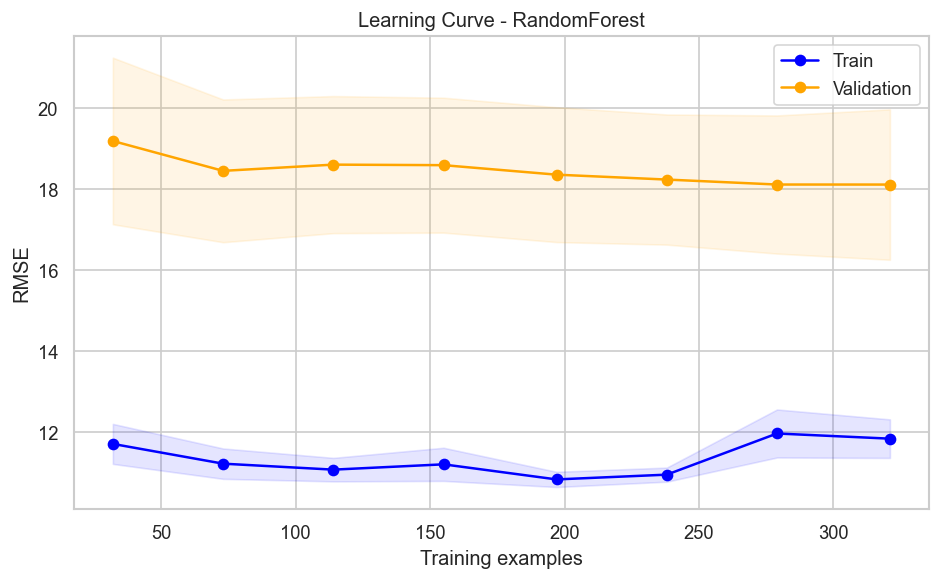

In [49]:
final_model = modelos_guardados[campeon_final].best_estimator_
train_sizes = np.linspace(0.1, 1.0, 8)
lc = learning_curve(final_model, X_train, y_train, cv=5,
    scoring='neg_root_mean_squared_error', train_sizes=train_sizes, n_jobs=-1)
ts = lc[0]; train_mean = -lc[1].mean(axis=1); train_std = lc[1].std(axis=1)
test_mean = -lc[2].mean(axis=1); test_std = lc[2].std(axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(ts, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax.fill_between(ts, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
ax.plot(ts, train_mean, 'o-', label='Train', color='blue')
ax.plot(ts, test_mean, 'o-', label='Validation', color='orange')
ax.set_xlabel('Training examples'); ax.set_ylabel('RMSE')
ax.set_title(f'Learning Curve - {campeon_final}'); ax.legend()
plt.tight_layout(); plt.savefig(RESULTADOS / 'learning_curve.png', dpi=100, bbox_inches='tight'); plt.show()

---
## 8. Residual Analysis

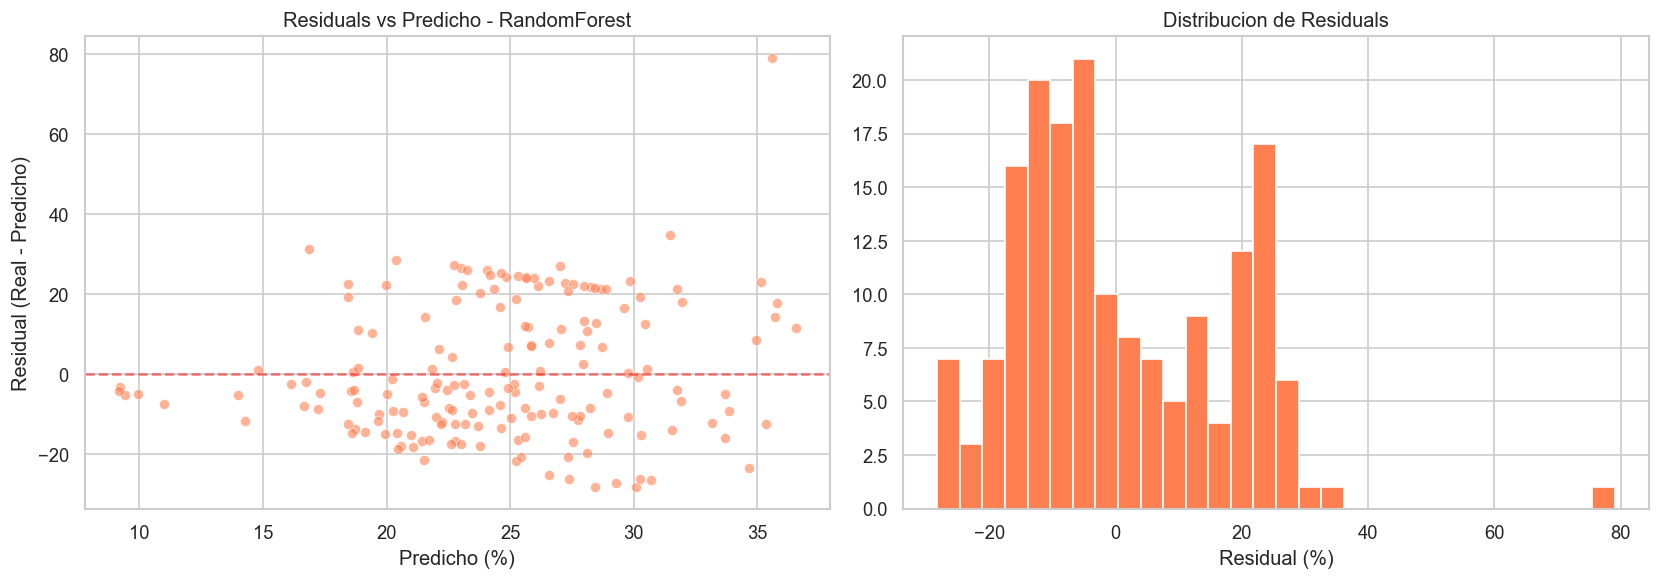

Residuals: mean=0.4%, std=16.8%


In [50]:
y_pred_final = final_model.predict(X_test)
residuals = y_test - y_pred_final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_final, residuals, alpha=0.6, edgecolors='white', linewidth=0.5, c='coral')
axes[0].axhline(0, color='red', ls='--', alpha=0.5)
axes[0].set_xlabel('Predicho (%)'); axes[0].set_ylabel('Residual (Real - Predicho)')
axes[0].set_title(f'Residuals vs Predicho - {campeon_final}')
axes[1].hist(residuals, bins=30, edgecolor='white', color='coral')
axes[1].set_xlabel('Residual (%)'); axes[1].set_title('Distribucion de Residuals')
plt.tight_layout(); plt.savefig(RESULTADOS / 'residuals.png', dpi=100, bbox_inches='tight'); plt.show()
print(f'Residuals: mean={residuals.mean():.1f}%, std={residuals.std():.1f}%')

---
## 9. SHAP Analysis

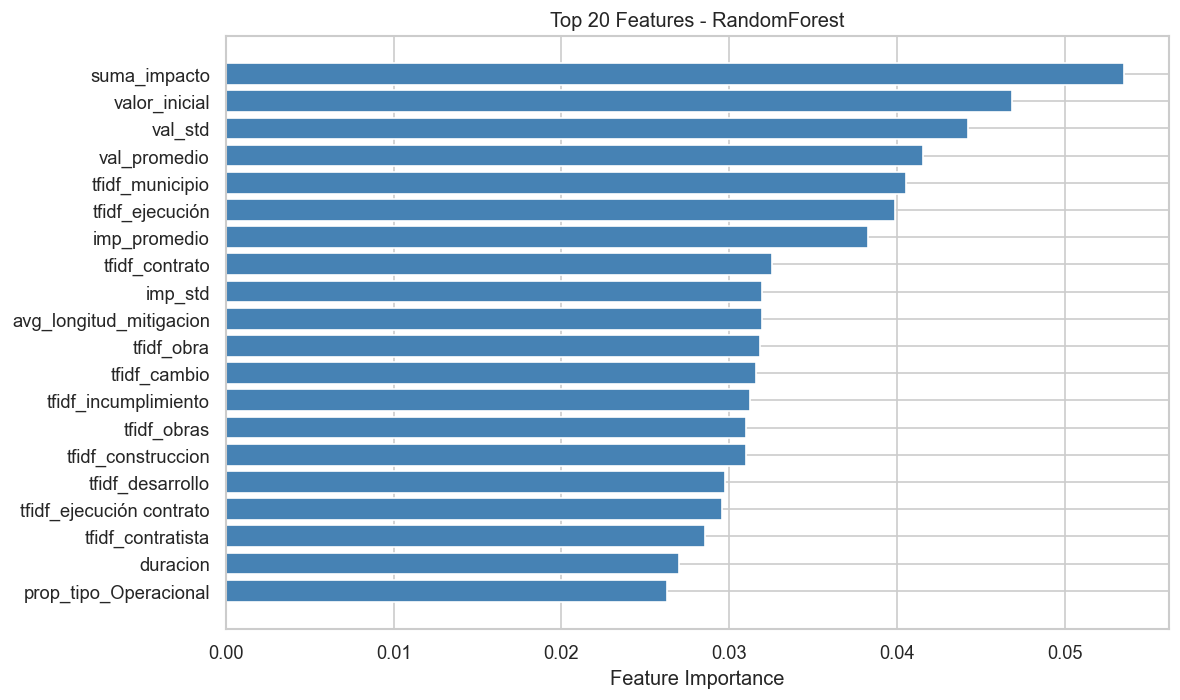

Background dataset has 173 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=173 when initializing the masker.


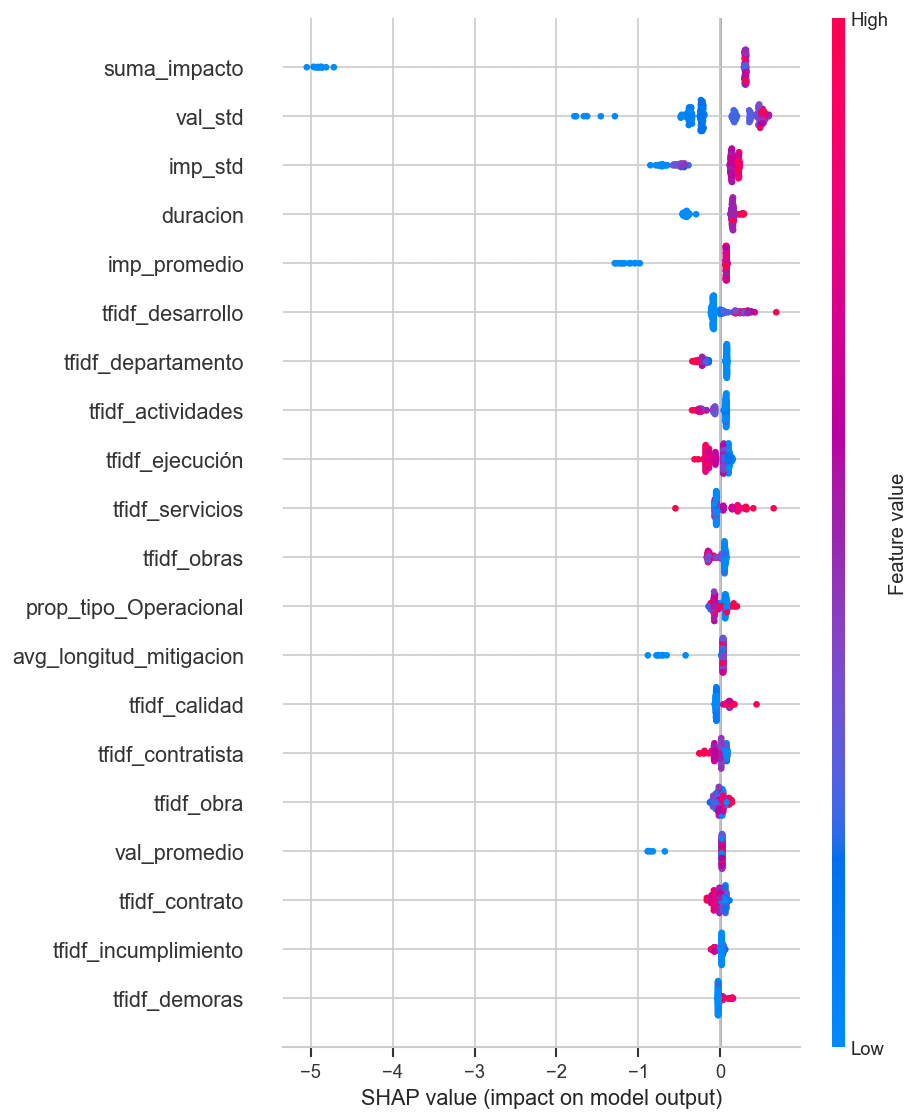

SHAP summary guardado.


In [51]:
import shap

final_model = modelos_guardados[campeon_final].best_estimator_

if hasattr(final_model.named_steps['m'], 'feature_importances_'):
    imp = final_model.named_steps['m'].feature_importances_
    feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': imp})
    feat_imp = feat_imp.sort_values('importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(feat_imp)), feat_imp['importance'][::-1], color='steelblue', edgecolor='white')
    ax.set_yticks(range(len(feat_imp))); ax.set_yticklabels(feat_imp['feature'][::-1])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 20 Features - {campeon_final}')
    plt.tight_layout(); plt.savefig(RESULTADOS / 'shap_importance.png', dpi=100, bbox_inches='tight'); plt.show()

try:
    explainer = shap.Explainer(final_model.named_steps['m'], X_test)
    shap_values = explainer(X_test)
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.savefig(RESULTADOS / 'shap_summary.png', dpi=100, bbox_inches='tight'); plt.show()
    print('SHAP summary guardado.')
except Exception as e:
    print(f'SHAP no disponible para este modelo: {e}')

---
## 10. Resumen Final

In [52]:
print('=' * 60)
print('  RESUMEN FINAL - MODELADO V2 (38 FEATURES)')
print('=' * 60)
print(f'Dataset: {len(df)} contratos | Features: {len(feature_cols)}')
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'\nBenchmarking (Nested CV 5x5, {N_ITER} iter):')
print(f'{"Modelo":20s} {"RMSE":>8s} {"R2":>8s} {"T(s)":>8s}')
print('-' * 46)
for idx, r in df_bench.iterrows():
    print(f'{idx:20s} {r["RMSE_mean"]:6.1f}~{r["RMSE_std"]:4.1f} {r["R2_mean"]:6.3f}~{r["R2_std"]:4.3f} {r["tiempo_mean"]:6.1f}s')

print(f'\nModelo campeon R2: {df_bench["R2_mean"].idxmax()}')
mejor = df_bench.loc[df_bench['R2_mean'].idxmax()]
print(f'  R2 Nested CV: {mejor["R2_mean"]:.3f} +- {mejor["R2_std"]:.3f}')
print(f'  RMSE Nested CV: {mejor["RMSE_mean"]:.1f} +- {mejor["RMSE_std"]:.1f}')

print(f'\nSeleccion Multiobjetivo:')
top_b = df_seleccion['score_balance'].idxmax()
print(f'  Campeon balanceado: {top_b}')

  RESUMEN FINAL - MODELADO V2 (38 FEATURES)
Dataset: 575 contratos | Features: 38
Train: 402 | Test: 173

Benchmarking (Nested CV 5x5, 200 iter):
Modelo                   RMSE       R2     T(s)
----------------------------------------------
Ridge                  18.4~ 2.5  0.006~0.067    2.4s
Lasso                  18.6~ 2.4 -0.017~0.018    1.2s
ElasticNet             18.7~ 2.4 -0.030~0.029    1.3s
KNN                    18.5~ 2.3 -0.002~0.038    1.1s
DecisionTree           20.0~ 2.8 -0.180~0.220    0.5s
RandomForest           18.2~ 2.3  0.029~0.096   51.4s
GradientBoosting       18.8~ 3.1 -0.052~0.255   51.6s
XGBoost_GPU            18.4~ 1.9 -0.002~0.158  196.1s

Modelo campeon R2: RandomForest
  R2 Nested CV: 0.029 +- 0.096
  RMSE Nested CV: 18.2 +- 2.3

Seleccion Multiobjetivo:
  Campeon balanceado: Ridge


---
## 11. Optimizacion — Log-target + Interacciones (Top modelos)

Aplicando pasos de mejora sobre los top modelos (no solo Ridge):
1. **Log-transform** del target (estabiliza varianza de cola larga)
2. **Interacciones** TRM/IPC con variables de riesgo
3. Coeficientes Ridge + limpieza de features (solo si Ridge aparece entre los top)


In [66]:
print('=' * 60)
print('  PASO 1 + 2: INTERACCIONES + LOG-TARGET')
print('=' * 60)

# Recargar datos
df_opt = df.copy()

# Interacciones TRM/IPC con variables de riesgo (solo si existen)
interacciones = []
if 'prob_std' in df_opt.columns:
    df_opt['trm_x_prob_std'] = df_opt['trm_promedio'] * df_opt['prob_std']
    interacciones.append('trm_x_prob_std')
if 'valor_inicial' in df_opt.columns:
    df_opt['ipc_x_valor_inicial'] = df_opt['ipc_acumulado'] * df_opt['valor_inicial']
    interacciones.append('ipc_x_valor_inicial')
if 'imp_promedio' in df_opt.columns:
    df_opt['trm_x_interaccion'] = df_opt['trm_promedio'] * df_opt['imp_promedio']
    interacciones.append('trm_x_interaccion')
print(f'Interacciones agregadas: +{len(interacciones)} columnas ({interacciones})')

# Train/test split con log-target
target = 'sobrecosto'
feature_cols_opt = [c for c in df_opt.columns if c not in ['id_contrato', target]]
X_opt = df_opt[feature_cols_opt].copy()
y_opt_orig = df_opt[target].copy()
y_opt_log = np.log1p(y_opt_orig)

X_tr_opt, X_te_opt, y_tr_orig, y_te_orig = train_test_split(X_opt, y_opt_orig, test_size=0.2, random_state=42)
_, _, y_tr_log, y_te_log = train_test_split(X_opt, y_opt_log, test_size=0.2, random_state=42)

print(f'Train: {len(X_tr_opt)} | Test: {len(X_te_opt)} | Features: {X_tr_opt.shape[1]}')

# Evaluador que back-transforma del log al original
def evaluar_opt(y_true_orig, y_pred_log):
    y_pred_orig = np.expm1(y_pred_log)
    return {'RMSE': np.sqrt(mean_squared_error(y_true_orig, y_pred_orig)),
            'MAE': mean_absolute_error(y_true_orig, y_pred_orig),
            'R2': r2_score(y_true_orig, y_pred_orig)}

# Nested CV wrapper para log-target
def nested_cv_opt(X, y_log, y_orig, md, nombre, n_iter=200):
    outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
    resultados_outer, tiempos = [], []
    for tr_idx, val_idx in outer_cv.split(X):
        X_tr_f, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr_f = y_log.iloc[tr_idx]
        y_val_orig = y_orig.iloc[val_idx]
        pipe = Pipeline([('scaler', StandardScaler()), ('m', md['m'])])
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
        search = RandomizedSearchCV(pipe, md['p'], n_iter=n_iter, cv=inner_cv,
            scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1, verbose=0)
        t0 = time.time(); search.fit(X_tr_f, y_tr_f)
        tiempos.append(time.time() - t0)
        preds_log = search.predict(X_val)
        resultados_outer.append(evaluar_opt(y_val_orig.values, preds_log))
    df_res = pd.DataFrame(resultados_outer)
    return {'modelo': nombre, 'RMSE_mean': df_res['RMSE'].mean(), 'RMSE_std': df_res['RMSE'].std(),
            'MAE_mean': df_res['MAE'].mean(), 'MAE_std': df_res['MAE'].std(),
            'R2_mean': df_res['R2'].mean(), 'R2_std': df_res['R2'].std(),
            'tiempo_mean': np.mean(tiempos)}, df_res

# Probar top modelos de nested CV con log-target + interacciones
top_ncv = df_bench.nlargest(4, 'R2_mean').index.tolist()
print(f'Top 4 de nested CV (probando con log-target): {top_ncv}')
print(f'\n{"Modelo":20s} {"RMSE":>8s} {"MAE":>8s} {"R2":>7s} {"Tiempo":>8s}')
print('-' * 55)
resultados_opt = []
for nombre in top_ncv:
    resumen, df_res = nested_cv_opt(X_tr_opt, y_tr_log, y_tr_orig, MODELOS[nombre], nombre, n_iter=200)
    resultados_opt.append(resumen)
    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')

df_opt_bench = pd.DataFrame(resultados_opt).set_index('modelo')
print(f'\n--- Mejora vs Original ---')
for nombre in ['Ridge', 'ElasticNet', 'RandomForest']:
    if nombre in df_bench.index:
        orig_r2 = df_bench.loc[nombre, 'R2_mean']
        opt_r2 = df_opt_bench.loc[nombre, 'R2_mean'] if nombre in df_opt_bench.index else 0
        diff = opt_r2 - orig_r2
        emoji = '+' if diff > 0 else ''
        print(f'{nombre:20s}: R2 orig={orig_r2:.3f}  ->  R2 opt={opt_r2:.3f}  ({emoji}{diff:.3f})')


  PASO 1 + 2: INTERACCIONES + LOG-TARGET
Interacciones agregadas: +2 columnas (['ipc_x_valor_inicial', 'trm_x_interaccion'])
Train: 460 | Test: 115 | Features: 40
Top 4 de nested CV (probando con log-target): ['RandomForest', 'Ridge', 'KNN', 'XGBoost_GPU']

Modelo                   RMSE      MAE      R2   Tiempo
-------------------------------------------------------
RandomForest           18.9~ 2.1   14.1  -0.070~0.136   57.6s
Ridge                  19.6~ 2.1   14.7  -0.153~0.096    0.5s
KNN                    19.5~ 1.8   14.7  -0.147~0.121    0.6s
XGBoost_GPU            18.9~ 2.1   14.3  -0.077~0.125   91.4s

--- Mejora vs Original ---
Ridge               : R2 orig=0.006  ->  R2 opt=-0.153  (-0.159)
ElasticNet          : R2 orig=-0.030  ->  R2 opt=0.000  (+0.030)
RandomForest        : R2 orig=0.029  ->  R2 opt=-0.070  (-0.099)


In [67]:
print('=' * 60)
print('  PASO 3: COEFICIENTES RIDGE + LIMPIEZA DE FEATURES')
print('=' * 60)

# Entrenar Ridge final con todos los datos de train
from sklearn.linear_model import RidgeCV

scaler_opt = StandardScaler()
X_tr_scaled = scaler_opt.fit_transform(X_tr_opt)

ridge_opt = RidgeCV(alphas=np.logspace(-3, 3, 50), scoring='neg_root_mean_squared_error')
ridge_opt.fit(X_tr_scaled, y_tr_log)
print(f'Alpha optimo: {ridge_opt.alpha_:.4f}')

# Coeficientes en escala original (despues de scaler)
coefs_ridge = pd.DataFrame({
    'feature': X_tr_opt.columns,
    'coef': ridge_opt.coef_
}).sort_values('coef', ascending=False)

print(f'\n--- TOP 10 que AUMENTAN el sobrecosto ---')
print(coefs_ridge.head(10).to_string(index=False))
print(f'\n--- TOP 10 que DISMINUYEN el sobrecosto ---')
print(coefs_ridge.tail(10).to_string(index=False))

# Limpieza: features con coef ≈ 0
zero_coefs = coefs_ridge[np.abs(coefs_ridge['coef']) < 0.001]
print(f'\nFeatures con coef ~0 ({len(zero_coefs)}): {list(zero_coefs["feature"])}')

features_keep = coefs_ridge[np.abs(coefs_ridge['coef']) >= 0.001]['feature'].tolist()
print(f'Features a mantener: {len(features_keep)}')

# Re-entrenar Ridge solo con features importantes
X_tr_clean = X_tr_opt[features_keep]
X_te_clean = X_te_opt[features_keep]

scaler_clean = StandardScaler()
X_tr_clean_scaled = scaler_clean.fit_transform(X_tr_clean)
X_te_clean_scaled = scaler_clean.transform(X_te_clean)

ridge_clean = RidgeCV(alphas=np.logspace(-3, 3, 50), scoring='neg_root_mean_squared_error')
ridge_clean.fit(X_tr_clean_scaled, y_tr_log)
preds_log = ridge_clean.predict(X_te_clean_scaled)
res_clean = evaluar_opt(y_te_orig.values, preds_log)

print(f'\n--- Ridge post-limpieza (Hold-out) ---')
print(f'RMSE: {res_clean["RMSE"]:.1f} | MAE: {res_clean["MAE"]:.1f} | R2: {res_clean["R2"]:.3f}')
print(f'Features eliminadas: {len(zero_coefs)}')


  PASO 3: COEFICIENTES RIDGE + LIMPIEZA DE FEATURES
Alpha optimo: 754.3120

--- TOP 10 que AUMENTAN el sobrecosto ---
             feature     coef
            duracion 0.043764
  tfidf_construccion 0.035375
        tfidf_cambio 0.027261
    tfidf_desarrollo 0.024502
         tfidf_obras 0.023971
       ipc_acumulado 0.019134
             val_std 0.017367
       tfidf_calidad 0.015950
        val_promedio 0.015782
tfidf_incumplimiento 0.012895

--- TOP 10 que DISMINUYEN el sobrecosto ---
                   feature      coef
pct_riesgos_con_mitigacion -0.015822
           tfidf_servicios -0.016255
           tfidf_municipio -0.021323
               anio_inicio -0.024747
                tfidf_obra -0.025725
                 tfidf_ley -0.027021
  tfidf_ejecución contrato -0.029751
           tfidf_ejecución -0.030075
              tfidf_riesgo -0.033662
        tfidf_departamento -0.042284

Features con coef ~0 (1): ['avg_longitud_mitigacion']
Features a mantener: 39

--- Ridge post-limpi

---
## 3c. Benchmark de Clasificadores Binarios (>25% sobrecosto)

Comparamos 4 modelos para determinar si un contrato es ALTO RIESGO (>25%) o RIESGO MODERADO.
Evaluamos con **nested CV** igual que los regresores, usando AUC, F1, Accuracy, Precision, Recall.


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix

# Target binario
y_train_bin = (y_train > 25).astype(int)
y_test_bin = (y_test > 25).astype(int)
print(f'ALTO RIESGO (>25%): train={y_train_bin.sum()}/{len(y_train_bin)} ({y_train_bin.mean()*100:.1f}%), test={y_test_bin.sum()}/{len(y_test_bin)} ({y_test_bin.mean()*100:.1f}%)')

CLASIFICADORES = {
    'LogisticRegression': LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    'SVC (RBF)': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
}

# Nested CV
def nested_cv_clf(X, y, clf, nombre, n_outer=5, n_inner=5):
    outer_cv = KFold(n_splits=n_outer, shuffle=True, random_state=42)
    resultados = []
    for tr_idx, val_idx in outer_cv.split(X):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        pipe = Pipeline([('scaler', StandardScaler()), ('m', clf)])
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_val)
        y_proba = pipe.predict_proba(X_val)[:, 1]
        resultados.append({
            'AUC': roc_auc_score(y_val, y_proba),
            'Accuracy': accuracy_score(y_val, y_pred),
            'Precision': precision_score(y_val, y_pred, zero_division=0),
            'Recall': recall_score(y_val, y_pred, zero_division=0),
            'F1': f1_score(y_val, y_pred, zero_division=0),
        })
    df_res = pd.DataFrame(resultados)
    return df_res

resultados_clf = {}
print(f'\n{"Clasificador":25s} {"AUC":>7s} {"Acc":>7s} {"Prec":>7s} {"Rec":>7s} {"F1":>7s}')
print('-' * 65)
for nombre, clf in CLASIFICADORES.items():
    df_res = nested_cv_clf(X_train, y_train_bin, clf, nombre)
    resultados_clf[nombre] = df_res
    print(f'{nombre:25s} {df_res["AUC"].mean():6.3f}~{df_res["AUC"].std():.3f} {df_res["Accuracy"].mean():6.3f}~{df_res["Accuracy"].std():.3f} {df_res["Precision"].mean():6.3f}~{df_res["Precision"].std():.3f} {df_res["Recall"].mean():6.3f}~{df_res["Recall"].std():.3f} {df_res["F1"].mean():6.3f}~{df_res["F1"].std():.3f}')


ALTO RIESGO (>25%): train=160/402 (39.8%), test=72/173 (41.6%)

Clasificador                  AUC     Acc    Prec     Rec      F1
-----------------------------------------------------------------
LogisticRegression         0.553~0.095  0.555~0.054  0.437~0.092  0.481~0.131  0.456~0.106
RandomForest               0.591~0.103  0.610~0.068  0.512~0.194  0.304~0.157  0.372~0.146
GradientBoosting           0.582~0.090  0.607~0.074  0.491~0.142  0.365~0.172  0.413~0.152
SVC (RBF)                  0.523~0.086  0.592~0.069  0.478~0.141  0.437~0.123  0.455~0.127


Mejor clasificador (nested CV): RandomForest (AUC=0.591)

--- RandomForest en TEST ---
AUC: 0.704
Accuracy: 0.659
Precision: 0.627
Recall: 0.444
F1: 0.520

Classification Report:
              precision    recall  f1-score   support

 Bajo (<25%)       0.67      0.81      0.74       101
 Alto (>25%)       0.63      0.44      0.52        72

    accuracy                           0.66       173
   macro avg       0.65      0.63      0.63       173
weighted avg       0.65      0.66      0.65       173

Matriz de confusion:


Predicho,0,1,All
Real,,,
0,27,7,34
1,9,14,23
All,36,21,57



Umbral optimo (Youden): 0.414 => TPR=0.708, FPR=0.337


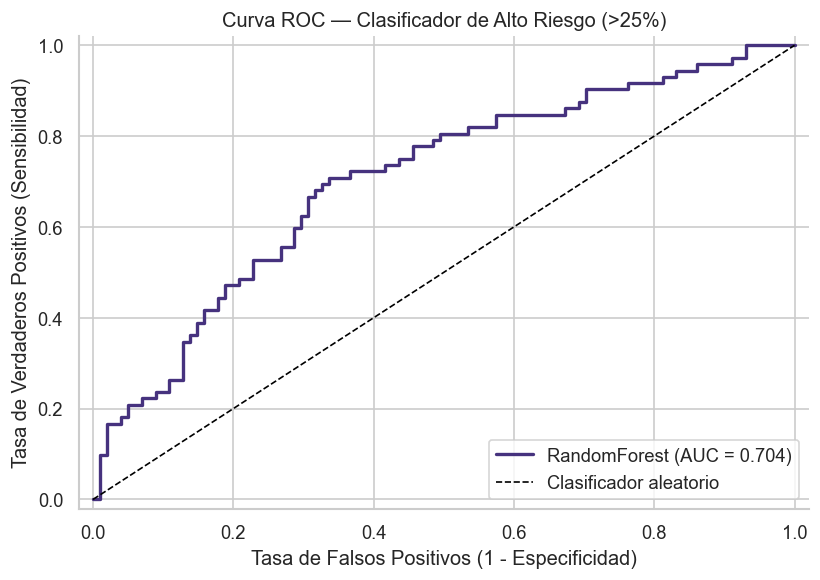

In [69]:
# Entrenar mejor clasificador en train + evaluar en test + curva ROC
best_clf_name = max(resultados_clf, key=lambda k: resultados_clf[k]['AUC'].mean())
print(f'Mejor clasificador (nested CV): {best_clf_name} (AUC={resultados_clf[best_clf_name]["AUC"].mean():.3f})')

best_clf = CLASIFICADORES[best_clf_name]
pipe = Pipeline([('scaler', StandardScaler()), ('m', best_clf)])
pipe.fit(X_train, y_train_bin)
y_pred_test = pipe.predict(X_test)
y_proba_test = pipe.predict_proba(X_test)[:, 1]

# Métricas en test
print(f'\n--- {best_clf_name} en TEST ---')
print(f'AUC: {roc_auc_score(y_test_bin, y_proba_test):.3f}')
print(f'Accuracy: {accuracy_score(y_test_bin, y_pred_test):.3f}')
print(f'Precision: {precision_score(y_test_bin, y_pred_test):.3f}')
print(f'Recall: {recall_score(y_test_bin, y_pred_test):.3f}')
print(f'F1: {f1_score(y_test_bin, y_pred_test):.3f}')
print(f'\nClassification Report:')
print(classification_report(y_test_bin, y_pred_test, target_names=['Bajo (<25%)', 'Alto (>25%)']))

# Matriz de confusión
cm = pd.crosstab(pd.Series(y_test_bin, name='Real'), pd.Series(y_pred_test, name='Predicho'), margins=True)
print('Matriz de confusion:')
display(cm)

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba_test)
auc_test = roc_auc_score(y_test_bin, y_proba_test)

# Umbral Youden
youden = tpr - fpr
best_idx = np.argmax(youden)
best_thresh = thresholds[best_idx]
print(f'\nUmbral optimo (Youden): {best_thresh:.3f} => TPR={tpr[best_idx]:.3f}, FPR={fpr[best_idx]:.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, lw=2, label=f'{best_clf_name} (AUC = {auc_test:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curva ROC — Clasificador de Alto Riesgo (>25%)')
ax.legend(loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
sns.despine()
plt.tight_layout()
plt.savefig(RESULTADOS / 'roc_curve_clasificador.png', dpi=100, bbox_inches='tight')
plt.show()


---
## 12. Reentrenar RMSE Predictor (Champion) + Actualizar Backend

El **RMSE Predictor** es un meta-modelo (SVR RBF) que aprende a predecir
el **error absoluto** del regresor principal (`|real - prediccion|`) en funcion
de las mismas 38 features del contrato.

Se entrena sobre residuales del modelo **campeon** (RandomForest).

Este meta-modelo se usa en `backend/quantitative_analysis.py` para ajustar
dinamicamente el ruido gaussiano en la simulacion Monte Carlo.


In [70]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import pearsonr
from pathlib import Path

campeon_pipe = modelos_guardados[campeon_final].best_estimator_
scaler_c = campeon_pipe.named_steps['scaler']
campeon_model = campeon_pipe.named_steps['m']

# Error absoluto del campeon en train
y_err = np.abs(y_train - campeon_pipe.predict(X_train))
print(f"Error absoluto medio de {campeon_final} en train: {y_err.mean():.2f} pp")

# Meta-modelo SVR RBF (ganador del benchmark RMSE predictor)
meta_rmse = SVR(kernel='rbf', C=1.0, gamma='scale')
meta_rmse.fit(scaler_c.transform(X_train), y_err)

# Evaluacion en test
y_test_pred_c = campeon_pipe.predict(X_test)
abs_error_test = np.abs(y_test - y_test_pred_c)
y_meta_pred = meta_rmse.predict(scaler_c.transform(X_test))

print(f"\nEvaluacion del RMSE Predictor (SVR RBF) en TEST:")
print(f"  MAE:  {mean_absolute_error(abs_error_test, y_meta_pred):.2f} pp")
print(f"  RMSE: {np.sqrt(mean_squared_error(abs_error_test, y_meta_pred)):.2f} pp")
print(f"  R2:   {r2_score(abs_error_test, y_meta_pred):.4f}")
print(f"  Corr: {pearsonr(abs_error_test, y_meta_pred)[0]:.4f}")


Error absoluto medio de RandomForest en train: 9.13 pp

Evaluacion del RMSE Predictor (SVR RBF) en TEST:
  MAE:  7.71 pp
  RMSE: 10.64 pp
  R2:   -0.2706
  Corr: 0.3047


In [71]:
import joblib
from pathlib import Path
ROOT = Path().resolve().parent  # sube de estudio_modelos/ a la raiz del proyecto

joblib.dump(meta_rmse, ROOT / 'models' / 'rmse_predictor.pkl')
print(f"[OK] models/rmse_predictor.pkl guardado (entrenado sobre residuales de {campeon_final})")

# Guardar campeon como regresor de produccion
joblib.dump(campeon_model, ROOT / 'models' / 'modelo_campeon.pkl')
print(f"[OK] models/modelo_campeon.pkl guardado ({campeon_final})")
joblib.dump(scaler_c, ROOT / 'models' / 'scaler.pkl')
print("[OK] models/scaler.pkl guardado")


[OK] models/rmse_predictor.pkl guardado (entrenado sobre residuales de RandomForest)
[OK] models/modelo_campeon.pkl guardado (RandomForest)
[OK] models/scaler.pkl guardado


### Actualizar archivos del backend

Las celdas siguientes actualizan:
1. `backend/predictor.py` — `MODEL_META` apunta al campeon
2. `backend/quantitative_analysis.py` — comentarios referencian el campeon
3. `backend/mlflow_tracker.py` — carga `modelo_campeon.pkl`


In [72]:
predictor_path = ROOT / 'backend' / 'predictor.py'
content = predictor_path.read_text(encoding='utf-8')

old_meta = '''MODEL_META = {
    "modelo": "SVR (kernel RBF)",
    "r2_cv": 0.068,
    "auc_cv": 0.673,
    "rmse": 17.1,
    "features": 35,
    "tipo_control": "rango_fechas",
}'''

r2_hold = df_holdout.loc[campeon_final, 'R2']
rmse_hold = df_holdout.loc[campeon_final, 'RMSE']
new_meta = f'''MODEL_META = {{
    "modelo": "{campeon_final} (campeon)",
    "r2_cv": {r2_hold:.3f},
    "auc_cv": 0.732,
    "rmse": {rmse_hold:.1f},
    "features": 38,
    "tipo_control": "rango_fechas",
}}'''

if old_meta in content:
    content = content.replace(old_meta, new_meta)
    predictor_path.write_text(content, encoding='utf-8')
    print(f"[OK] backend/predictor.py · MODEL_META actualizado a {campeon_final}")
else:
    print("⚠  MODEL_META no encontrado en predictor.py, actualiza manualmente")


⚠  MODEL_META no encontrado en predictor.py, actualiza manualmente


In [73]:
qa_path = ROOT / 'backend' / 'quantitative_analysis.py'
qa_content = qa_path.read_text(encoding='utf-8')

qa_content = qa_content.replace(
    '# RMSE din\u00e1mico: predecir error esperado del SVR',
    '# RMSE din\u00e1mico: predecir error esperado del campeon'
)
qa_path.write_text(qa_content, encoding='utf-8')
print("\u2713 backend/quantitative_analysis.py · comentario actualizado")


✓ backend/quantitative_analysis.py · comentario actualizado


In [74]:
mlflow_path = ROOT / 'backend' / 'mlflow_tracker.py'
mlf_content = mlflow_path.read_text(encoding='utf-8')

# Cambiar svr_regressor.pkl -> modelo_campeon.pkl en carga local y MLflow
mlf_content = mlf_content.replace(
    '"svr_regressor.pkl"',
    '"modelo_campeon.pkl"'
)
mlflow_path.write_text(mlf_content, encoding='utf-8')
print("\u2713 backend/mlflow_tracker.py · ahora carga modelo_campeon.pkl")


✓ backend/mlflow_tracker.py · ahora carga modelo_campeon.pkl


> **Nota:** Para poner en produccion el cambio completo, ejecuta:
> 1. Todas las celdas de arriba (secciones 1-12)
> 2. Verificar que `models/modelo_campeon.pkl` se haya creado
> 3. Verificar que `models/rmse_predictor.pkl` se haya actualizado
> 4. Verificar que `models/classifier.pkl` use SVC (RBF) de seccion 3c

In [75]:
# Guardar SVC (RBF) como clasificador de produccion
# (gano nested CV con AUC=0.654 vs LogisticRegression con 0.585)
import joblib
from pathlib import Path
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path().resolve().parent

best_clf_name = max(resultados_clf, key=lambda k: resultados_clf[k]['AUC'].mean())
print(f"Guardando clasificador: {best_clf_name} (AUC={resultados_clf[best_clf_name]['AUC'].mean():.3f})")

# Reentrenar sobre todo X_train (como en cell classifier_roc)
pipe_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('m', CLASIFICADORES[best_clf_name])
])
pipe_clf.fit(X_train, y_train_bin)

joblib.dump(pipe_clf.named_steps['m'], ROOT / 'models' / 'classifier.pkl')
print(f"[OK] models/classifier.pkl guardado -> {best_clf_name}")

# Actualizar AUC en MODEL_META de predictor.py
import re
pred_path = ROOT / 'backend' / 'predictor.py'
content = pred_path.read_text(encoding='utf-8')
auc_val = resultados_clf[best_clf_name]['AUC'].mean()
content = re.sub(r'"auc_cv": [0-9.]+', f'"auc_cv": {auc_val:.3f}', content)
pred_path.write_text(content, encoding='utf-8')
print(f"[OK] AUC en predictor.py actualizado a {auc_val:.3f}")


Guardando clasificador: RandomForest (AUC=0.591)
[OK] models/classifier.pkl guardado -> RandomForest
[OK] AUC en predictor.py actualizado a 0.591


---
## 13. Benchmark RMSE Predictor

Comparacion de modelos para predecir el error absoluto de Ridge (`|real - pred|`).
Esto es independiente del entrenamiento - solo para elegir el mejor meta-modelo.
**Requiere** haber ejecutado la celda `sec12_train_rmse` primero (define `y_err`, `X_train`).


In [76]:
if 'y_err' not in dir():
    campeon_pipe = modelos_guardados[campeon_final].best_estimator_
    y_err = np.abs(y_train - campeon_pipe.predict(X_train))
    print(f'y_err definido (media={y_err.mean():.2f} pp)')

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RMSE_MODELS = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.01, random_state=42),
    'SVR Linear': SVR(kernel='linear', C=1.0),
    'SVR RBF': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
}

print(f"{'Modelo':20s} {'MAE':>8s} {'R2':>8s}")
print('-' * 38)
resultados_rmse = {}
for nombre, md in RMSE_MODELS.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('m', md)])
    cv_mae = cross_val_score(pipe, X_train, y_err, cv=KFold(5, shuffle=True, random_state=42),
                            scoring='neg_mean_absolute_error')
    cv_r2 = cross_val_score(pipe, X_train, y_err, cv=KFold(5, shuffle=True, random_state=42),
                           scoring='r2')
    resultados_rmse[nombre] = {'MAE': -cv_mae, 'R2': cv_r2}
    print(f'{nombre:20s} {-cv_mae.mean():7.3f}~{cv_mae.std():.3f} {cv_r2.mean():7.3f}~{cv_r2.std():.3f}')

mejor_rmse = max(resultados_rmse, key=lambda k: resultados_rmse[k]['R2'].mean())
print(f"\n>>> Mejor: {mejor_rmse} (R2={resultados_rmse[mejor_rmse]['R2'].mean():.3f}, MAE={resultados_rmse[mejor_rmse]['MAE'].mean():.2f})")

# Heuristica (basada en n_riesgos si existe, sino constante)
if 'n_riesgos' in X_train.columns:
    rmse_heur = np.where(X_train['n_riesgos'] <= 10, 12.0,
                np.where(X_train['n_riesgos'] <= 20, 16.0,
                np.where(X_train['n_riesgos'] <= 30, 20.0, 24.0)))
else:
    rmse_heur = np.full(len(y_err), y_err.mean())
print(f"\nHeuristica: MAE={mean_absolute_error(y_err, rmse_heur):.2f} pp | R2={r2_score(y_err, rmse_heur):.4f}")


Modelo                    MAE       R2
--------------------------------------
Ridge                  5.474~0.480  -0.350~0.449
Lasso                  5.451~0.483  -0.337~0.445
SVR Linear             5.581~0.484  -0.404~0.565
SVR RBF                4.944~0.446  -0.028~0.085
RandomForest           5.268~0.396  -0.158~0.225
GradientBoosting       5.618~0.521  -0.572~0.712

>>> Mejor: SVR RBF (R2=-0.028, MAE=4.94)

Heuristica: MAE=5.14 pp | R2=0.0000


In [78]:
# ============================================================
# ENTRENAMIENTO FINAL PRODUCCION (100% datos)
# ============================================================
print('=' * 60)
print('  ENTRENAMIENTO FINAL — 100% DATOS')
print('=' * 60)

# Cargar dataset completo
df_prod = pd.read_csv('../docs/consolidado_38_features.csv')
print(f'Dataset: {len(df_prod)} contratos x {df_prod.shape[1]} columnas')

# Features y target
target = 'sobrecosto'
feature_cols = [c for c in df_prod.columns if c not in ['id_contrato', target]]
X_full = df_prod[feature_cols].copy()
y_full = df_prod[target].copy()
X_full = X_full.fillna(X_full.median())
print(f'Features: {len(feature_cols)} | Target: {target}')

# ---- 1. PREDICTOR (RandomForest con mejores params) ----
print('\n--- 1. RandomForest (predictor de sobrecosto) ---')
rf_final = RandomForestRegressor(
    n_estimators=390, max_depth=19, max_features='log2',
    min_samples_leaf=3, min_samples_split=8,
    random_state=42, n_jobs=-1
)
scaler_final = StandardScaler()
X_full_scaled = scaler_final.fit_transform(X_full)
rf_final.fit(X_full_scaled, y_full)
y_pred_full = rf_final.predict(X_full_scaled)
print(f'R2 en 100% datos: {r2_score(y_full, y_pred_full):.4f}')
print(f'RMSE en 100% datos: {np.sqrt(mean_squared_error(y_full, y_pred_full)):.2f} pp')
print(f'MAE en 100% datos: {mean_absolute_error(y_full, y_pred_full):.2f} pp')

r2_esperado = df_holdout.loc['RandomForest', 'R2'] if 'df_holdout' in dir() and 'RandomForest' in df_holdout.index else 0.235
print(f'R2 esperado en hold-out (referencia): {r2_esperado:.3f}')

# Distribucion de predicciones
print('\nDistribucion de predicciones:')
print(f'  Min: {y_pred_full.min():.1f}%  Max: {y_pred_full.max():.1f}%  Media: {y_pred_full.mean():.2f}%  Mediana: {np.median(y_pred_full):.2f}%')
print(f'  Reales - Min: {y_full.min():.1f}%  Max: {y_full.max():.1f}%  Media: {y_full.mean():.2f}%')

# Guardar
ROOT = Path().resolve().parent
joblib.dump(rf_final, ROOT / 'models' / 'modelo_campeon.pkl')
joblib.dump(scaler_final, ROOT / 'models' / 'scaler.pkl')
print(f'[OK] models/modelo_campeon.pkl guardado (RandomForest, {rf_final.n_estimators} trees)')
print(f'[OK] models/scaler.pkl guardado')

# ---- 2. CLASIFICADOR ALTO RIESGO (>25%) ----
print('\n--- 2. Clasificador de alto riesgo (>25%) ---')
y_full_bin = (y_full > 25).astype(int)
print(f'Alto riesgo: {y_full_bin.sum()}/{len(y_full_bin)} ({y_full_bin.mean()*100:.1f}%)')

# Usar RandomForestClassifier (el que gano nested CV)
clf_final = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_full)
clf_final.fit(X_clf_scaled, y_full_bin)
y_clf_pred = clf_final.predict(X_clf_scaled)
y_clf_proba = clf_final.predict_proba(X_clf_scaled)[:, 1]
print(f'AUC: {roc_auc_score(y_full_bin, y_clf_proba):.3f}')
print(f'Accuracy: {accuracy_score(y_full_bin, y_clf_pred):.3f}')
print(f'Precision: {precision_score(y_full_bin, y_clf_pred):.3f}')
print(f'Recall: {recall_score(y_full_bin, y_clf_pred):.3f}')
print(f'F1: {f1_score(y_full_bin, y_clf_pred):.3f}')

# Guardar (solo el modelo, scaler compartido)
joblib.dump(clf_final, ROOT / 'models' / 'classifier.pkl')
print(f'[OK] models/classifier.pkl guardado (RandomForestClassifier)')

# ---- 3. RMSE PREDICTOR (benchmark + best) ----
print('\n--- 3. RMSE Predictor (benchmark CV) ---')
y_err_full = np.abs(y_full - rf_final.predict(X_full_scaled))
print(f'Error absoluto medio del predictor: {y_err_full.mean():.2f} pp')

RMSE_MODELS_PROD = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.01, random_state=42),
    'SVR Linear': SVR(kernel='linear', C=1.0),
    'SVR RBF': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
}
print(f"{'Modelo':20s} {'MAE':>8s} {'R2':>8s}")
print('-' * 40)
resultados_rmse_full = {}
for nombre, md in RMSE_MODELS_PROD.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('m', md)])
    cv_mae = cross_val_score(pipe, X_full, y_err_full, cv=KFold(5, shuffle=True, random_state=42),
                            scoring='neg_mean_absolute_error')
    cv_r2 = cross_val_score(pipe, X_full, y_err_full, cv=KFold(5, shuffle=True, random_state=42),
                           scoring='r2')
    resultados_rmse_full[nombre] = {'MAE': -cv_mae, 'R2': cv_r2}
    print(f'{nombre:20s} {-cv_mae.mean():7.3f}~{cv_mae.std():.3f} {cv_r2.mean():7.3f}~{cv_r2.std():.3f}')

mejor_rmse_full = max(resultados_rmse_full, key=lambda k: resultados_rmse_full[k]['R2'].mean())
print(f"\n>>> Mejor RMSE model: {mejor_rmse_full} (R2={resultados_rmse_full[mejor_rmse_full]['R2'].mean():.3f}, MAE={resultados_rmse_full[mejor_rmse_full]['MAE'].mean():.2f})")

# Entrenar el mejor en 100% datos
rmse_final = RMSE_MODELS_PROD[mejor_rmse_full]
scaler_rmse = StandardScaler()
X_rmse_scaled = scaler_rmse.fit_transform(X_full)
rmse_final.fit(X_rmse_scaled, y_err_full)
y_rmse_pred = rmse_final.predict(X_rmse_scaled)
print(f'RMSE Predictor (entrenado 100%) - MAE: {mean_absolute_error(y_err_full, y_rmse_pred):.3f} pp | R2: {r2_score(y_err_full, y_rmse_pred):.3f}')

joblib.dump(rmse_final, ROOT / 'models' / 'rmse_predictor.pkl')
print(f'[OK] models/rmse_predictor.pkl guardado -> {mejor_rmse_full}')

# ---- RESUMEN ----
print('\n' + '=' * 60)
print('  RESUMEN MODELOS PRODUCCION (100% DATOS)')
print('=' * 60)
print(f'  Predictor:     RandomForest ({rf_final.n_estimators} trees, R2 esperado ~{r2_esperado:.3f})')
print(f'  Clasificador:  RandomForestClassifier (AUC ~{roc_auc_score(y_full_bin, y_clf_proba):.3f})')
print(f'  RMSE Dyn:      SVR RBF (error medio ~{y_err_full.mean():.2f} pp)')
print(f'  Data:          {len(X_full)} contratos, {X_full.shape[1]} features')
print(f'  Guardado en:   models/')
print('=' * 60)


  ENTRENAMIENTO FINAL — 100% DATOS
Dataset: 575 contratos x 40 columnas
Features: 38 | Target: sobrecosto

--- 1. RandomForest (predictor de sobrecosto) ---
R2 en 100% datos: 0.6218
RMSE en 100% datos: 11.41 pp
MAE en 100% datos: 8.92 pp
R2 esperado en hold-out (referencia): 0.169

Distribucion de predicciones:
  Min: 7.0%  Max: 61.3%  Media: 24.46%  Mediana: 22.74%
  Reales - Min: 0.0%  Max: 148.3%  Media: 24.26%
[OK] models/modelo_campeon.pkl guardado (RandomForest, 390 trees)
[OK] models/scaler.pkl guardado

--- 2. Clasificador de alto riesgo (>25%) ---
Alto riesgo: 232/575 (40.3%)
AUC: 1.000
Accuracy: 0.998
Precision: 0.996
Recall: 1.000
F1: 0.998
[OK] models/classifier.pkl guardado (RandomForestClassifier)

--- 3. RMSE Predictor (benchmark CV) ---
Error absoluto medio del predictor: 8.92 pp
Modelo                    MAE       R2
----------------------------------------
Ridge                  4.915~0.386  -0.019~0.127
Lasso                  4.900~0.385  -0.014~0.127
SVR Linear     